In [1]:
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

Training trajectories shape: torch.Size([1000, 100, 24])
Training controls shape: torch.Size([1000, 99, 2])
Testing trajectories shape: torch.Size([215, 100, 24])
Testing controls shape: torch.Size([215, 99, 2])


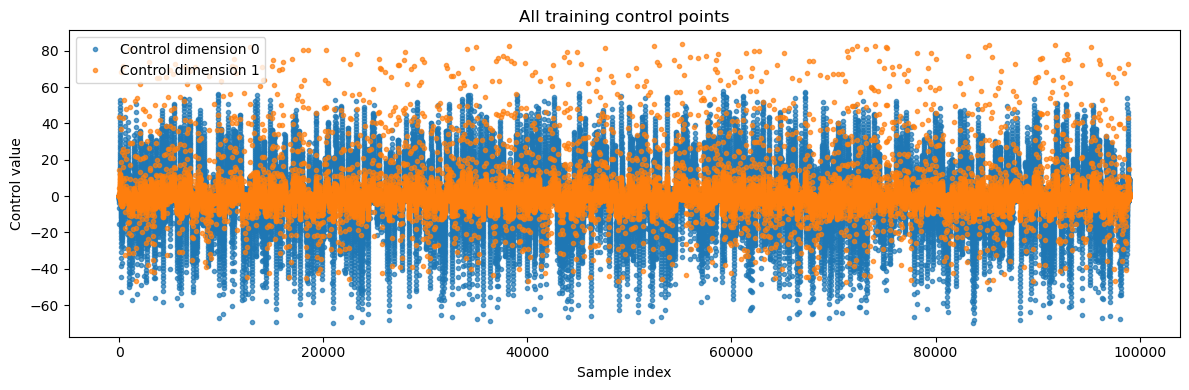

In [2]:
import load

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
trajectories_tensor_train = load.trajectories_tensor_train
controls_tensor_train = load.controls_tensor_train
trajectories_tensor_test = load.trajectories_tensor_test
controls_tensor_test = load.controls_tensor_test

In [5]:
batch_size = 32

torch_dataset_train = TensorDataset(trajectories_tensor_train, controls_tensor_train)
torch_dataset_test = TensorDataset(trajectories_tensor_test, controls_tensor_test)

train_dataloader = DataLoader(torch_dataset_train,
                              batch_size=batch_size,
                              shuffle=True)

test_dataloader = DataLoader(torch_dataset_test,
                             batch_size=batch_size,
                             shuffle=False)

In [6]:
trajectory, controls = next(iter(train_dataloader))
#print(controls.shape,controls[0,-1,0])
#plt.plot(controls[0,:,1].numpy())
print("batch trajectory shape:", trajectory.shape)
print("batch controls shape:", controls.shape)
print("one trajectory shape:", trajectory[0].shape)
print("one control shape:", controls[0].shape)
print("one state shape:", trajectory[0, 0].shape)

batch trajectory shape: torch.Size([32, 100, 24])
batch controls shape: torch.Size([32, 99, 2])
one trajectory shape: torch.Size([100, 24])
one control shape: torch.Size([99, 2])
one state shape: torch.Size([24])


In [7]:
feature_dim = 24      # dimension of the marker/state space
hidden_layers = 5     # number of hidden layers
latent_dim = 8        # Koopman latent dimension

In [8]:
class Encoder(nn.Module):
    def __init__(self, layer_dims: list[int]):
        super().__init__()

        layers = []
        for in_dim, out_dim in zip(layer_dims[:-2], layer_dims[1:-1]):
            layers.append(nn.Linear(in_dim, out_dim))
            layers.append(nn.ELU())
        layers.append(nn.Linear(layer_dims[-2], layer_dims[-1]))

        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [9]:
class Decoder(nn.Module):
    def __init__(self, layer_dims: list[int]):
        super().__init__()

        reversed_dims = list(reversed(layer_dims))

        layers = []
        for in_dim, out_dim in zip(reversed_dims[:-2], reversed_dims[1:-1]):
            layers.append(nn.Linear(in_dim, out_dim))
            layers.append(nn.ELU())

        layers.append(nn.Linear(reversed_dims[-2], reversed_dims[-1]))
        self.network = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.network(z)

In [10]:
class Autoencoder(nn.Module):
    def __init__(self, feature_dim: int, hidden_layers: int, latent_dim: int):
        super().__init__()

        layer_dims = [feature_dim + i * (latent_dim - feature_dim) // hidden_layers
            for i in range(hidden_layers)] + [latent_dim]

        self.encoder = Encoder(layer_dims)
        self.decoder = Decoder(layer_dims)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

In [11]:
autoencoder = Autoencoder(feature_dim, hidden_layers, latent_dim).to(device=device, dtype=torch.float64)
autoencoder.load_state_dict(torch.load("koopman_autoencoder_closed.pth", map_location=device))
autoencoder.eval()
print(autoencoder)

Autoencoder(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=24, out_features=20, bias=True)
      (1): ELU(alpha=1.0)
      (2): Linear(in_features=20, out_features=17, bias=True)
      (3): ELU(alpha=1.0)
      (4): Linear(in_features=17, out_features=14, bias=True)
      (5): ELU(alpha=1.0)
      (6): Linear(in_features=14, out_features=11, bias=True)
      (7): ELU(alpha=1.0)
      (8): Linear(in_features=11, out_features=8, bias=True)
    )
  )
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=8, out_features=11, bias=True)
      (1): ELU(alpha=1.0)
      (2): Linear(in_features=11, out_features=14, bias=True)
      (3): ELU(alpha=1.0)
      (4): Linear(in_features=14, out_features=17, bias=True)
      (5): ELU(alpha=1.0)
      (6): Linear(in_features=17, out_features=20, bias=True)
      (7): ELU(alpha=1.0)
      (8): Linear(in_features=20, out_features=24, bias=True)
    )
  )
)


In [12]:
def compute_AB_DMD_from_trajectory(autoencoder, trajectory, controls, m):
    """
    trajectory: tensor of shape [batch_size, T, feature_dim]
    controls: tensor of shape [batch_size, T-1, control_dim]
    m: number of time steps used to estimate A and B

    returns:
        A: tensor of shape [batch_size, latent_dim, latent_dim]
        B: tensor of shape [batch_size, latent_dim, control_dim]
        z: tensor of shape [batch_size, T, latent_dim]
    """

    z = autoencoder.encoder(trajectory)    # [batch_size, T, latent_dim]

    z_data = z[:, :m, :]                    # [batch_size, m, latent_dim]
    u_data = controls[:, :m-1, :]           # [batch_size, m-1, control_dim]

    Z1 = z_data[:, :-1, :].transpose(1, 2)   # [batch_size, latent_dim, m-1]
    Z2 = z_data[:, 1:, :].transpose(1, 2)    # [batch_size, latent_dim, m-1]
    U1 = u_data.transpose(1, 2)              # [batch_size, control_dim, m-1]

    ZU = torch.cat([Z1, U1], dim=1)
    ZU_T = ZU.transpose(1, 2)

    lam = 1e-4
    G = torch.bmm(ZU, ZU_T)

    I = torch.eye(G.shape[-1], device=G.device, dtype=G.dtype)
    I = I.unsqueeze(0).expand(G.shape[0], -1, -1)

    AB = torch.bmm(torch.bmm(Z2, ZU_T), torch.linalg.inv(G + lam * I))

    """
    ZU = torch.cat([Z1, U1], dim=1)           # [batch_size, latent_dim + control_dim, m-1]
    AB = torch.matmul(Z2, torch.linalg.pinv(ZU))
    """
    latent_dim = z.shape[-1]
    A = AB[:, :, :latent_dim]
    B = AB[:, :, latent_dim:]

    return A, B, z

In [13]:
trajectory, controls = next(iter(train_dataloader))
trajectory = trajectory.to(device=device, dtype=torch.float64)
controls = controls.to(device=device, dtype=torch.float64)

m = 50

A, B, z = compute_AB_DMD_from_trajectory(autoencoder, trajectory, controls, m)

print("trajectory shape:", trajectory.shape)
print("controls shape:", controls.shape)
print("latent trajectory shape:", z.shape)
print("A shape:", A.shape)
print("B shape:", B.shape)

trajectory shape: torch.Size([32, 100, 24])
controls shape: torch.Size([32, 99, 2])
latent trajectory shape: torch.Size([32, 100, 8])
A shape: torch.Size([32, 8, 8])
B shape: torch.Size([32, 8, 2])


In [14]:
def rollout_with_AB(A, B, z_start, future_controls):
    """
    A: [batch_size, latent_dim, latent_dim]
    B: [batch_size, latent_dim, control_dim]
    z_start: [batch_size, latent_dim]
    future_controls: [batch_size, pred_steps, control_dim]

    returns:
        z_pred: [batch_size, pred_steps, latent_dim]
    """

    z_current = z_start
    z_preds = []

    for i in range(future_controls.shape[1]):
        u_current = future_controls[:, i, :]
        state_part = torch.bmm(A, z_current.unsqueeze(2)).squeeze(2)
        control_part = torch.bmm(B, u_current.unsqueeze(2)).squeeze(2)
        z_current = state_part + control_part
        z_preds.append(z_current)

    z_pred = torch.stack(z_preds, dim=1)   # [batch_size, pred_steps, latent_dim]

    return z_pred


In [15]:
z_start = z[:, m - 1, :]                          # [batch_size, latent_dim]
future_controls = controls[:, m - 1:, :]          # [batch_size, T-m, control_dim]

z_pred = rollout_with_AB(A, B, z_start, future_controls)

print("z_start shape:", z_start.shape)
print("future controls shape:", future_controls.shape)
print("z_pred shape:", z_pred.shape)

z_start shape: torch.Size([32, 8])
future controls shape: torch.Size([32, 50, 2])
z_pred shape: torch.Size([32, 50, 8])


In [16]:
mse_loss = nn.MSELoss()

def koopman_controlled_trajectory_loss(autoencoder, trajectory, controls, m):
    """
    trajectory: [batch_size, T, feature_dim]
    controls: [batch_size, T-1, control_dim]
    m: number of time steps used to estimate A and B
    """

    A, B, z = compute_AB_DMD_from_trajectory(autoencoder, trajectory, controls, m)

    x_recon = autoencoder.decoder(z)
    loss_recon = mse_loss(x_recon[:, :m, :], trajectory[:, :m, :])

    z_start = z[:, m - 1, :]
    future_controls = controls[:, m - 1:, :]

    z_pred = rollout_with_AB(A, B, z_start, future_controls)
    x_pred = autoencoder.decoder(z_pred)

    loss_pred = mse_loss(x_pred, trajectory[:, m:, :])
    loss = loss_recon + loss_pred

    return loss, loss_recon, loss_pred


In [17]:
trajectory, controls = next(iter(train_dataloader))
trajectory = trajectory.to(device=device, dtype=torch.float64)
controls = controls.to(device=device, dtype=torch.float64)

m = 50

loss, loss_recon, loss_pred = koopman_controlled_trajectory_loss(autoencoder, trajectory, controls, m)

print("total loss:", loss.item())
print("reconstruction loss:", loss_recon.item())
print("prediction loss:", loss_pred.item())

total loss: 0.00033821559220428306
reconstruction loss: 0.0002712202403226373
prediction loss: 6.699535188164576e-05


In [18]:
learning_rate = 1e-3
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=learning_rate, weight_decay=1e-5)

In [68]:
num_epochs = 200
m = 50

train_loss_history = []
train_recon_history = []
train_pred_history = []

test_loss_history = []
test_recon_history = []
test_pred_history = []

for epoch in range(num_epochs):
    autoencoder.train()

    train_loss_sum = 0.0
    train_recon_sum = 0.0
    train_pred_sum = 0.0
    train_batches = 0

    for trajectory, controls in train_dataloader:
        trajectory = trajectory.to(device=device, dtype=torch.float64)
        controls = controls.to(device=device, dtype=torch.float64)

        optimizer.zero_grad()

        loss, loss_recon, loss_pred = koopman_controlled_trajectory_loss(autoencoder, trajectory, controls, m)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        train_recon_sum += loss_recon.item()
        train_pred_sum += loss_pred.item()
        train_batches += 1

    autoencoder.eval()

    test_loss_sum = 0.0
    test_recon_sum = 0.0
    test_pred_sum = 0.0
    test_batches = 0

    with torch.no_grad():
        for trajectory, controls in test_dataloader:
            trajectory = trajectory.to(device=device, dtype=torch.float64)
            controls = controls.to(device=device, dtype=torch.float64)

            loss, loss_recon, loss_pred = koopman_controlled_trajectory_loss(autoencoder, trajectory, controls, m)

            test_loss_sum += loss.item()
            test_recon_sum += loss_recon.item()
            test_pred_sum += loss_pred.item()
            test_batches += 1

    train_loss_epoch = train_loss_sum / train_batches
    train_recon_epoch = train_recon_sum / train_batches
    train_pred_epoch = train_pred_sum / train_batches

    test_loss_epoch = test_loss_sum / test_batches
    test_recon_epoch = test_recon_sum / test_batches
    test_pred_epoch = test_pred_sum / test_batches

    train_loss_history.append(train_loss_epoch)
    train_recon_history.append(train_recon_epoch)
    train_pred_history.append(train_pred_epoch)

    test_loss_history.append(test_loss_epoch)
    test_recon_history.append(test_recon_epoch)
    test_pred_history.append(test_pred_epoch)

    print(
        f"Epoch {epoch + 1:03d} | "
        f"train loss: {train_loss_epoch:.6f} | "
        f"train recon: {train_recon_epoch:.6f} | "
        f"train pred: {train_pred_epoch:.6f} | "
        f"test loss: {test_loss_epoch:.6f} | "
        f"test recon: {test_recon_epoch:.6f} | "
        f"test pred: {test_pred_epoch:.6f}"
    )


Epoch 001 | train loss: 0.387138 | train recon: 0.232989 | train pred: 0.154148 | test loss: 0.306818 | test recon: 0.186925 | test pred: 0.119893
Epoch 002 | train loss: 0.248401 | train recon: 0.149771 | train pred: 0.098631 | test loss: 0.189644 | test recon: 0.118744 | test pred: 0.070901
Epoch 003 | train loss: 0.141989 | train recon: 0.093556 | train pred: 0.048434 | test loss: 0.108627 | test recon: 0.076259 | test pred: 0.032368
Epoch 004 | train loss: 0.095549 | train recon: 0.067308 | train pred: 0.028240 | test loss: 0.090282 | test recon: 0.064443 | test pred: 0.025839
Epoch 005 | train loss: 0.080952 | train recon: 0.057108 | train pred: 0.023843 | test loss: 0.077430 | test recon: 0.055552 | test pred: 0.021878
Epoch 006 | train loss: 0.066969 | train recon: 0.047176 | train pred: 0.019793 | test loss: 0.059374 | test recon: 0.040684 | test pred: 0.018690
Epoch 007 | train loss: 0.044922 | train recon: 0.030962 | train pred: 0.013960 | test loss: 0.033423 | test recon: 0.

In [ ]:
#torch.save(autoencoder.state_dict(), "koopman_autoencoder_closed.pth")

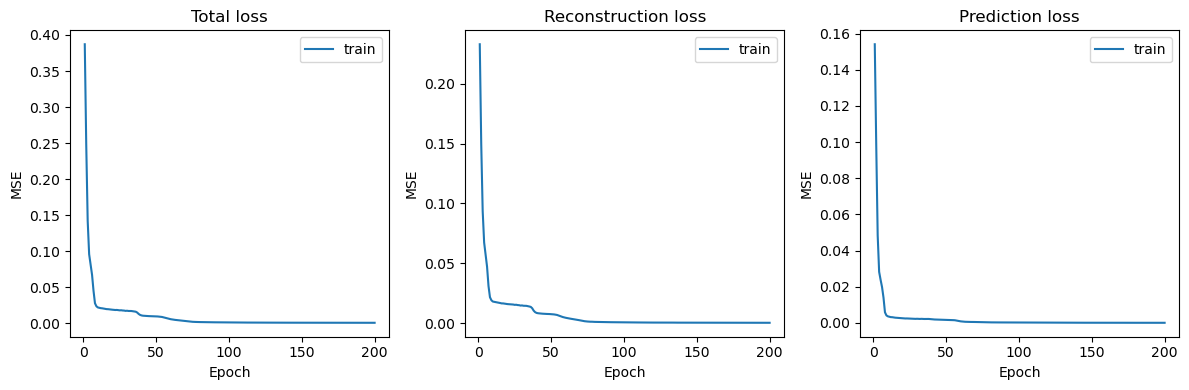

In [70]:
epochs = range(1, len(train_loss_history) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs, train_loss_history, label="train")
#plt.plot(epochs, test_loss_history, label="test")
plt.title("Total loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, train_recon_history, label="train")
#plt.plot(epochs, test_recon_history, label="test")
plt.title("Reconstruction loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, train_pred_history, label="train")
#plt.plot(epochs, test_pred_history, label="test")
plt.title("Prediction loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
def fit_global_AB_least_squares(autoencoder, dataloader, device, lam=0):
    """
    Fits one global Koopman model:

        z_{t+1} = A z_t + B u_t

    using all encoded training trajectories.
    """

    autoencoder.eval()

    Z1_list = []
    Z2_list = []
    U1_list = []

    with torch.no_grad():
        for trajectory, controls in dataloader:
            trajectory = trajectory.to(device=device, dtype=torch.float64)
            controls = controls.to(device=device, dtype=torch.float64)

            z = autoencoder.encoder(trajectory)   # [batch, T, latent_dim]

            z1 = z[:, :-1, :]                     # [batch, T-1, latent_dim]
            z2 = z[:, 1:, :]                      # [batch, T-1, latent_dim]
            u1 = controls                         # [batch, T-1, control_dim]

            Z1_list.append(z1.reshape(-1, z1.shape[-1]).T)
            Z2_list.append(z2.reshape(-1, z2.shape[-1]).T)
            U1_list.append(u1.reshape(-1, u1.shape[-1]).T)

    Z1 = torch.cat(Z1_list, dim=1)
    Z2 = torch.cat(Z2_list, dim=1)
    U1 = torch.cat(U1_list, dim=1)

    X = torch.cat([Z1, U1], dim=0)   # [N, latent_dim + control_dim]
    Y = Z2                           # [N, latent_dim]

    I = torch.eye(X.shape[0], device=device, dtype=torch.float64)

    AB = torch.linalg.solve(X @ X.T + lam * I, X @ Y.T).T

    latent_dim = Z1.shape[0]

    A_hot = AB[:, :latent_dim]
    B_hot = AB[:, latent_dim:]

    return A_hot, B_hot

In [20]:
A_hot, B_hot = fit_global_AB_least_squares(autoencoder, train_dataloader, device=device, lam=0)

print("A_hot shape:", A_hot.shape)
print("B_hot shape:", B_hot.shape)

A_hot shape: torch.Size([8, 8])
B_hot shape: torch.Size([8, 2])


In [21]:
def rollout_hot_start(A, B, z_start, controls):
    """
    A: [latent_dim, latent_dim]
    B: [latent_dim, control_dim]
    z_start: [batch, latent_dim]
    controls: [batch, pred_steps, control_dim]

    returns:
        z_pred: [batch, pred_steps, latent_dim]
    """

    z_current = z_start
    z_preds = []

    for t in range(controls.shape[1]):
        u = controls[:, t, :]

        z_current = z_current @ A.T + u @ B.T

        z_preds.append(z_current)

    return torch.stack(z_preds, dim=1)

Trajectory: traj_1006
Original shape         : (100, 24)
Reconstructed shape    : (100, 24)
Predicted shape : (99, 24)


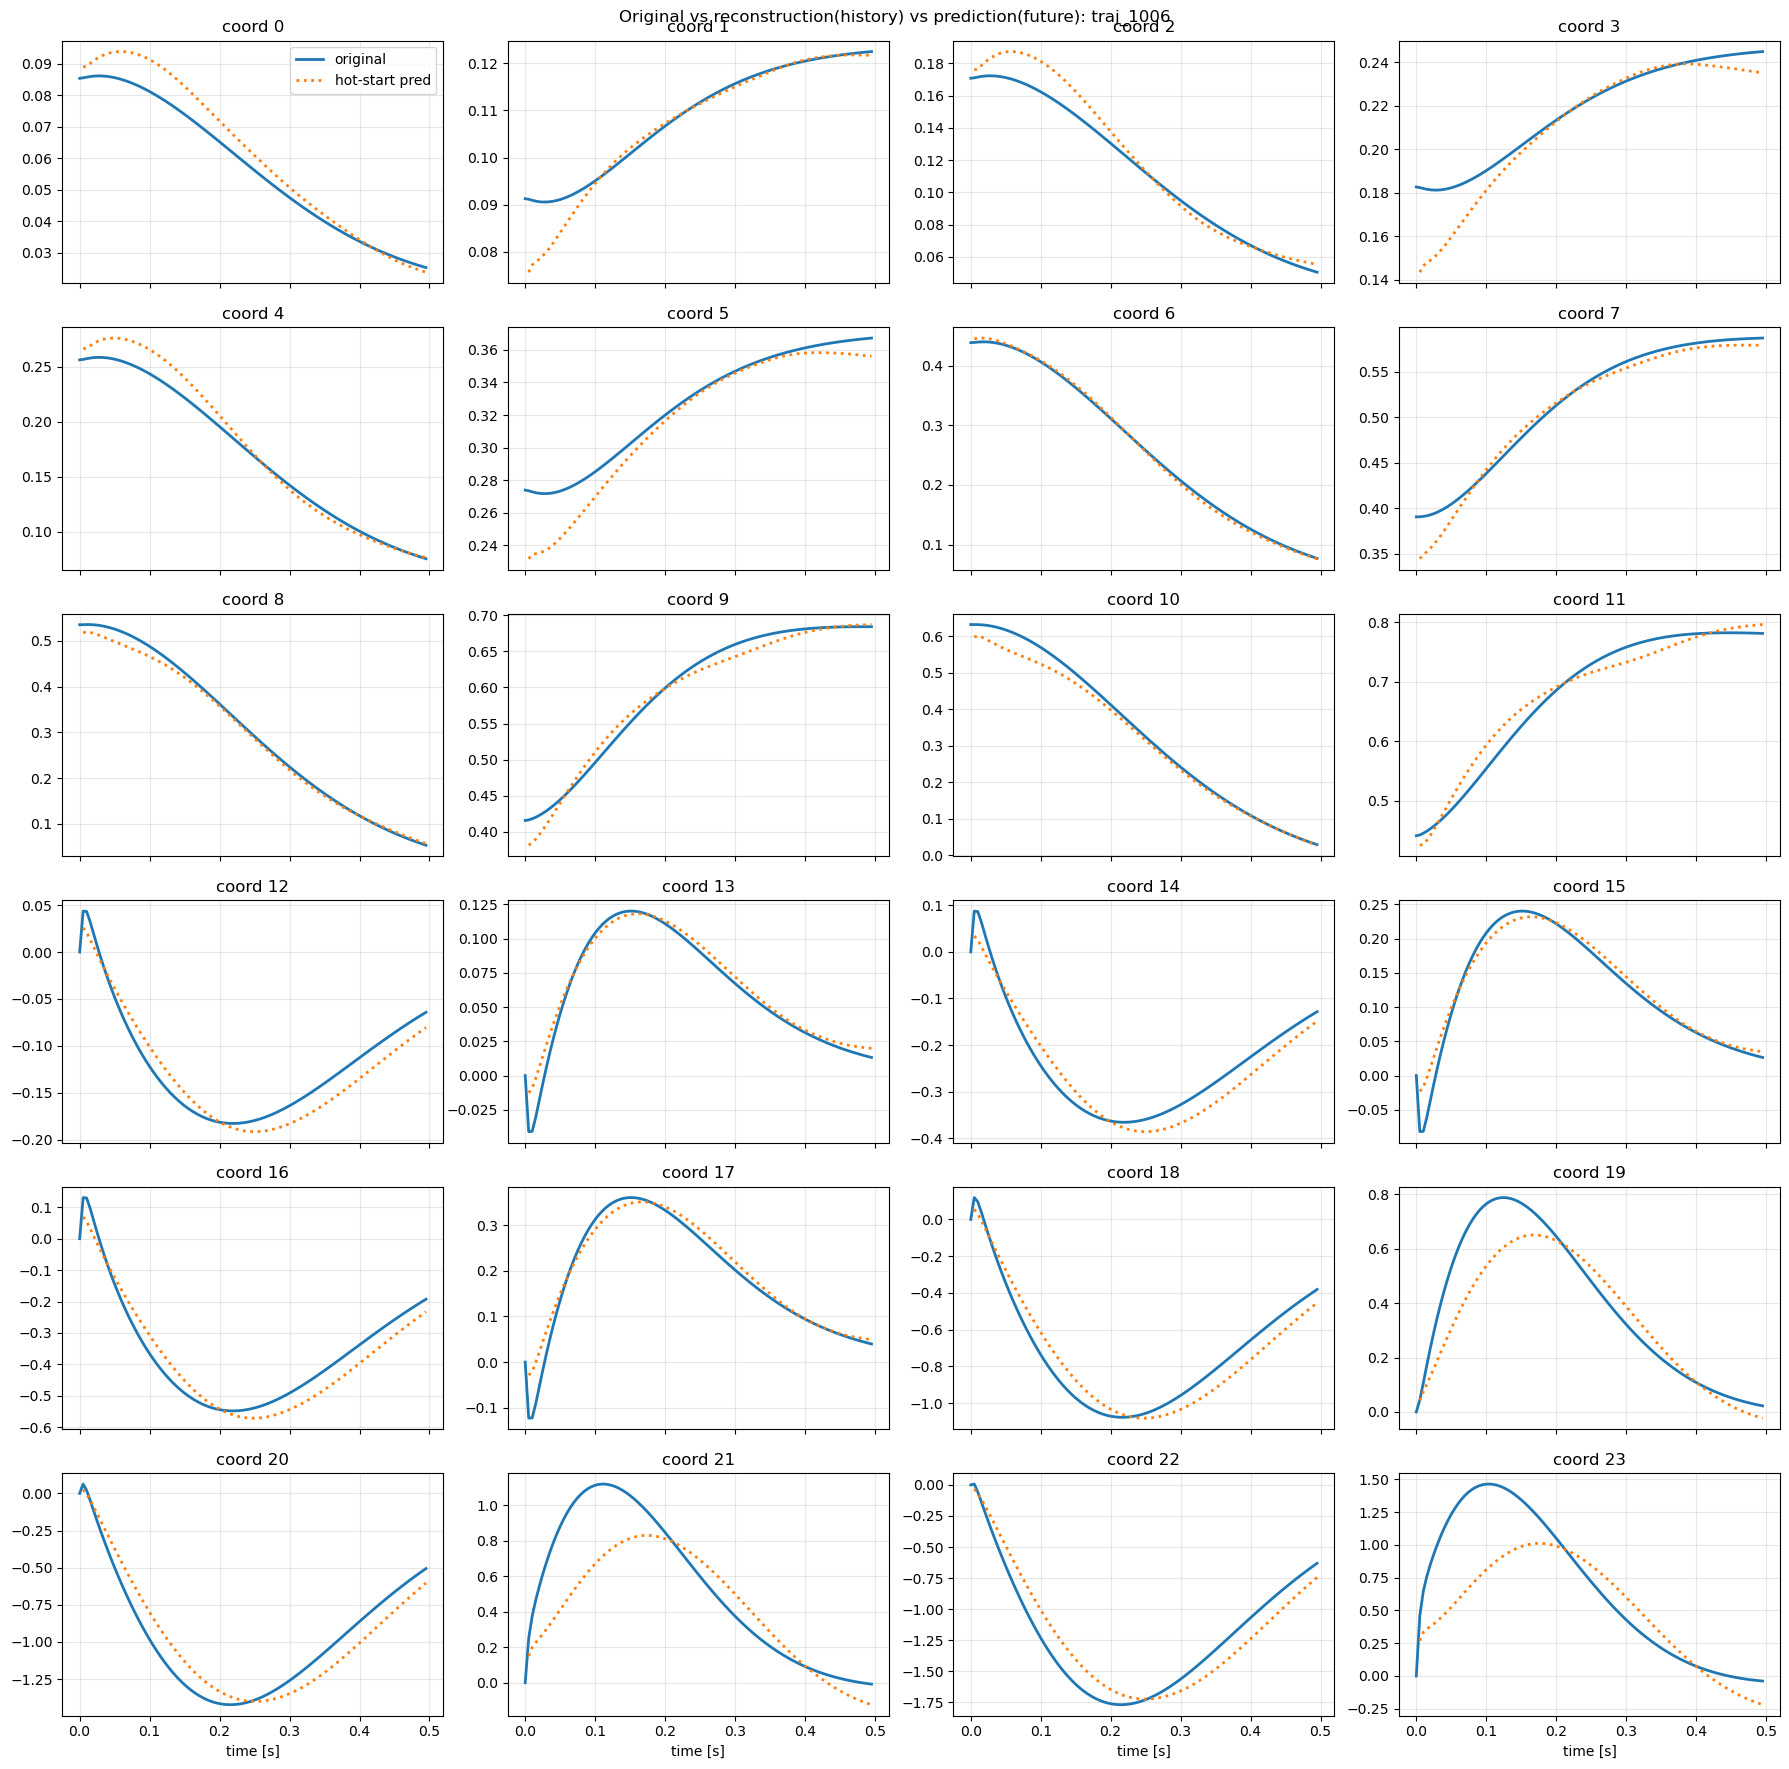

In [22]:
root = Path.cwd().resolve().parents[0]
val_dir = root / "data" / "val"

traj_dir = sorted([p for p in val_dir.iterdir() if p.is_dir()])[5]

observations_np = np.load(traj_dir / "observations.npy")   # (24, 100)
controls_np = np.load(traj_dir / "controls.npy")           # (2, 99)

dt = 0.005
time = np.arange(observations_np.shape[1]) * dt

trajectory = torch.from_numpy(observations_np.T).to(torch.float64).unsqueeze(0)
trajectory = trajectory.to(device) if "device" in globals() else trajectory
controls = torch.from_numpy(controls_np.T).to(torch.float64).unsqueeze(0)
controls = controls.to(device) if "device" in globals() else controls

autoencoder.eval()
with torch.no_grad():
    z = autoencoder.encoder(trajectory)

    # reconstruction over full trajectory
    x_recon = autoencoder.decoder(z)

    # hot-start prediction from the first state
    z_start = z[:, 0, :]
    future_controls = controls

    z_pred = rollout_hot_start(A_hot, B_hot, z_start, future_controls)
    x_pred = autoencoder.decoder(z_pred)

original = trajectory.squeeze(0).detach().cpu().numpy()          # (100, 24)
reconstructed = x_recon.squeeze(0).detach().cpu().numpy()        # (100, 24)
predicted = x_pred.squeeze(0).detach().cpu().numpy()  # (T-m, 24)

print("Trajectory:", traj_dir.name)
print("Original shape         :", original.shape)
print("Reconstructed shape    :", reconstructed.shape)
print("Predicted shape :", predicted.shape)

fig, axes = plt.subplots(6, 4, figsize=(18, 18), sharex=True)
axes = axes.flatten()

for idx in range(24):
    ax = axes[idx]

    ax.plot(time, original[:, idx], label="original", linewidth=2)
    #ax.plot(time, reconstructed[:, idx], "--", label="recon", linewidth=1.5)
    ax.plot(time[1:], predicted[:, idx], ":", label="hot-start pred", linewidth=2)

    ax.set_title(f"coord {idx}")
    ax.grid(True, alpha=0.3)
    
axes[0].legend(loc="best")
axes[-1].set_xlabel("time [s]")
axes[-2].set_xlabel("time [s]")
axes[-3].set_xlabel("time [s]")
axes[-4].set_xlabel("time [s]")

fig.suptitle(f"Original vs reconstruction(history) vs prediction(future): {traj_dir.name}")
fig.tight_layout()
plt.show()


In [23]:
import sys
import importlib
from pathlib import Path

repo_root = Path.cwd().resolve()

if not (repo_root / "data-generator").exists():
    repo_root = repo_root.parent

data_generator_dir = repo_root / "data-generator"

if str(data_generator_dir) not in sys.path:
    sys.path.append(str(data_generator_dir))

import params
from markers import get_marker_observation

params = importlib.reload(params)
p = params.get_params()

x_ref_np = get_marker_observation( p["q_target"], p["qdot_target"], p)

x_ref = torch.from_numpy(x_ref_np).to(device=device, dtype=torch.float64).unsqueeze(0)

autoencoder.eval()
with torch.no_grad():
    z_ref_true = autoencoder.encoder(x_ref).squeeze(0).detach().cpu().numpy()

print("x_ref shape:", x_ref.shape)
print("z_ref_true shape:", z_ref_true.shape)
print("q_target:", p["q_target"])
print("qdot_target:", p["qdot_target"])

x_ref shape: torch.Size([1, 24])
z_ref_true shape: (8,)
q_target: [ 2.0943951  -1.57079633]
qdot_target: [0. 0.]


In [24]:
from scipy.linalg import solve_discrete_are

def discrete_lqr_gain(A, B, Q, R):
    P = solve_discrete_are(A, B, Q, R)
    K = np.linalg.solve(R + B.T @ P @ B, B.T @ P @ A)
    return K

def latent_lqr_rollout(A, B, z_start, z_ref, u_ref, K, steps, u_clip=None):
    z_current = z_start
    z_preds = []
    u_preds = []

    for i in range(steps):
        u = u_ref - K @ (z_current - z_ref)

        if u_clip is not None:
            u = np.clip(u, -u_clip, u_clip)

        z_current = A @ z_current + B @ u

        z_preds.append(z_current)
        u_preds.append(u)

    return np.stack(z_preds), np.stack(u_preds)


||z_start - z_ref||: 2.2382926384256097


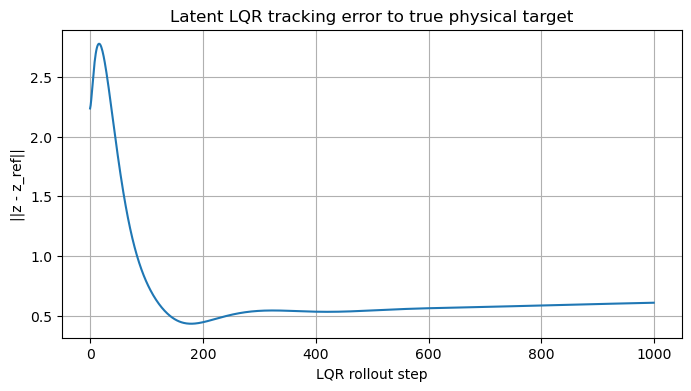

initial latent error: 2.2351629506493387
final latent error: 0.6086348353087808
relative final error: 0.2722999838253251


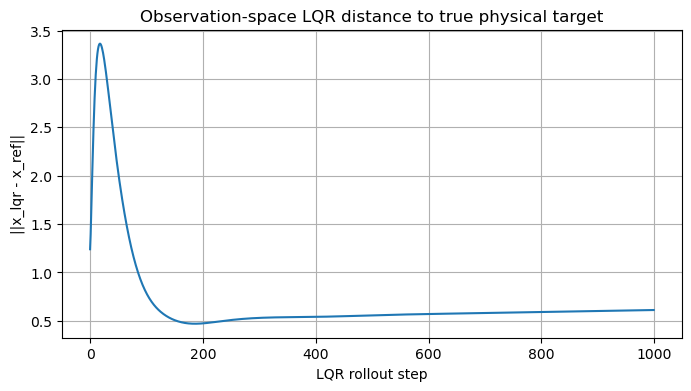

initial observation error: 1.2398624239085598
final observation error: 0.6114312320175467
relative final observation error: 0.4931444168539782


In [25]:
autoencoder.eval()
with torch.no_grad():
    z = autoencoder.encoder(trajectory)

A0 = A_hot.detach().cpu().numpy()
B0 = B_hot.detach().cpu().numpy()
z_np = z[0].detach().cpu().numpy()

# hot start from first state
z_start = z_np[0]
z_ref = z_ref_true

print("||z_start - z_ref||:", np.linalg.norm(z_start - z_ref))

u_ref = np.linalg.lstsq(B0, (np.eye(A0.shape[0]) - A0) @ z_ref, rcond=None)[0]

Q = np.eye(A0.shape[0])
R = 1e-2 * np.eye(B0.shape[1])

K = discrete_lqr_gain(A0, B0, Q, R)

z_lqr, u_lqr = latent_lqr_rollout(A0, B0, z_start, z_ref, u_ref, K, steps=1000, u_clip=None) # steps=trajectory.shape[1] - 1

z_lqr_torch = torch.from_numpy(z_lqr).to(device=device, dtype=torch.float64).unsqueeze(0)

with torch.no_grad():
    x_lqr = autoencoder.decoder(z_lqr_torch)

latent_error = np.linalg.norm(z_lqr - z_ref[None, :], axis=1)

plt.figure(figsize=(8, 4))
plt.plot(latent_error)
plt.xlabel("LQR rollout step")
plt.ylabel("||z - z_ref||")
plt.title("Latent LQR tracking error to true physical target")
plt.grid(True)
plt.show()

print("initial latent error:", latent_error[0])
print("final latent error:", latent_error[-1])
print("relative final error:", latent_error[-1] / latent_error[0])

x_lqr_np = x_lqr.squeeze(0).detach().cpu().numpy()
x_ref_np_eval = x_ref.squeeze(0).detach().cpu().numpy()
obs_error_lqr = np.linalg.norm(x_lqr_np - x_ref_np_eval[None, :], axis=1)

plt.figure(figsize=(8, 4))
plt.plot(obs_error_lqr)
plt.xlabel("LQR rollout step")
plt.ylabel("||x_lqr - x_ref||")
plt.title("Observation-space LQR distance to true physical target")
plt.grid(True)
plt.show()

print("initial observation error:", obs_error_lqr[0])
print("final observation error:", obs_error_lqr[-1])
print("relative final observation error:", obs_error_lqr[-1] / obs_error_lqr[0])

In [39]:
def check_reference_reachability(A, B, z_ref, tol=1e-12):
    import numpy as np
    import torch

    if isinstance(z_ref, np.ndarray):
        z_ref = torch.from_numpy(z_ref)

    z_ref = z_ref.to(device=A.device, dtype=A.dtype).squeeze()

    I = torch.eye(A.shape[0], device=A.device, dtype=A.dtype)

    v = (I - A) @ z_ref

    B_pinv = torch.linalg.pinv(B)
    u_ref_ls = B_pinv @ v

    v_projected = B @ u_ref_ls
    residual_vec = v - v_projected

    residual_norm = torch.norm(residual_vec)
    v_norm = torch.norm(v)
    relative_residual = residual_norm / (v_norm + 1e-12)
    if torch.allclose((B@B_pinv), torch.eye((B@B_pinv).shape[0], device=B_hot.device, dtype=B_hot.dtype), atol=1e-12):
         print("B_hot @ B_pinv_hot is the identity matrix")
    else:
         print("B_hot @ B_pinv_hot is NOT the identity matrix") 
        


    print("rank(B):", torch.linalg.matrix_rank(B).item())
    print("||v|| = ||(I-A)z_ref||:", v_norm.item())
    print("||v - BB^+v||:", residual_norm.item())
    #print("relative residual:", relative_residual.item())
    print("u_ref least-squares:", u_ref_ls.detach().cpu().numpy())

    if relative_residual < tol:
        print("Reachable: exact u_ref exists.")
    else:
        print("Not exactly reachable: LQR can settle with nonzero error.")

    return {
        "v": v,
        "u_ref_ls": u_ref_ls,
        "v_projected": v_projected,
        "residual_vec": residual_vec,
        "residual_norm": residual_norm,
        "relative_residual": relative_residual,
    }


results = check_reference_reachability(A_hot, B_hot, z_ref_true)


B_hot @ B_pinv_hot is NOT the identity matrix
rank(B): 2
||v|| = ||(I-A)z_ref||: 0.04206014461264527
||v - BB^+v||: 0.003948617231527741
u_ref least-squares: [-8.67482798 -6.64488745]
Not exactly reachable: LQR can settle with nonzero error.


In [28]:
from markers import get_marker_observation, physical_state_from_marker_observation
from scipy.integrate import solve_ivp
from dynamics import qddot

def real_dynamics_with_tau(t, state, tau, p):
    q = state[:2]
    qdot = state[2:]

    qdd = qddot(q, qdot, tau, p)

    return np.hstack([qdot, qdd])


def one_step_real_dynamics(state, tau, p):
    dt = p["dt"]

    sol = solve_ivp(
        fun=lambda t, x: real_dynamics_with_tau(t, x, tau, p),
        t_span=(0.0, dt),
        y0=state,
        t_eval=[dt],
        method="RK45",
        rtol=1e-7,
        atol=1e-9,
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    return sol.y[:, -1]

def encode_physical_state(autoencoder, state, p, device):
    obs_np = get_marker_observation(state[:2], state[2:], p)

    obs = (torch.from_numpy(obs_np).to(device=device, dtype=torch.float64).unsqueeze(0))

    autoencoder.eval()
    with torch.no_grad():
        z = autoencoder.encoder(obs)

    return z.squeeze(0).detach().cpu().numpy(), obs_np

In [29]:
# Use first point of the unseen validation trajectory
obs0_real = observations_np[:, 0]  # shape: (24,)

# Send observation directly into the encoder
obs0_torch = (torch.from_numpy(obs0_real).to(device=device, dtype=torch.float64).unsqueeze(0))

autoencoder.eval()
with torch.no_grad():
    z0_real = autoencoder.encoder(obs0_torch)

z0_real = z0_real.squeeze(0).detach().cpu().numpy()

# One latent LQR control
u0 = u_ref - K @ (z0_real - z_ref)

# RLS-compatible notation
AB0 = np.concatenate([A0, B0], axis=1)      # shape: (latent_dim, latent_dim + control_dim)
ZU0 = np.concatenate([z0_real, u0], axis=0) # shape: (latent_dim + control_dim,)

# Learned latent one-step prediction using the control u0
z1_pred = AB0 @ ZU0

# Convert initial marker observation to physical state [q1, q2, q1dot, q2dot]
x0_real = physical_state_from_marker_observation(obs0_real, p)

# Apply u0 to the real dynamics for one time step
x1_real = one_step_real_dynamics(x0_real, u0, p)

# Convert the next physical state into marker observation
obs1_real = get_marker_observation(x1_real[:2], x1_real[2:], p)

# Encode the next real observation into latent space
obs1_torch = (torch.from_numpy(obs1_real).to(device=device, dtype=torch.float64).unsqueeze(0))

autoencoder.eval()
with torch.no_grad():
    z1_real = autoencoder.encoder(obs1_torch)

z1_real = z1_real.squeeze(0).detach().cpu().numpy()

# Prediction error: measured encoded next state minus learned latent prediction
e0 = z1_real - z1_pred

print("prediction error e0 = z1_real - z1_pred:", e0)
print("||e0||:", np.linalg.norm(e0))

prediction error e0 = z1_real - z1_pred: [ 0.45496521  0.01571871  0.18085949 -0.22517895 -0.00135853  0.10625213
 -0.1543536   0.29102366]
||e0||: 0.6406772197217749


In [30]:
lambda_rls = 0.999
alpha = 1

latent_dim = A0.shape[0]
control_dim = B0.shape[1]
zu_dim = latent_dim + control_dim

# Initial covariance
P0 = alpha * np.eye(zu_dim)

# RLS gain
P0_ZU0 = P0 @ ZU0
denominator = lambda_rls + ZU0.T @ P0_ZU0
K0_rls = P0_ZU0 / denominator

# Update AB
AB1 = AB0 + np.outer(e0, K0_rls)

# Update covariance
P1 = (P0 - np.outer(K0_rls, ZU0.T @ P0)) / lambda_rls

# Optional numerical cleanup
#P1 = 0.5 * (P1 + P1.T)

# Recover A and B
A1 = AB1[:, :latent_dim]
B1 = AB1[:, latent_dim:]

z1_pred_before = AB0 @ ZU0
z1_pred_after = AB1 @ ZU0

error_before = z1_real - z1_pred_before
error_after = z1_real - z1_pred_after

print("error before RLS:", np.linalg.norm(error_before))
print("error after RLS:", np.linalg.norm(error_after))

error before RLS: 0.6406772197217749
error after RLS: 0.0018856677291104174


In [31]:
# Use the pre-RLS predicted z1 as the latent state for the next control
z1_for_control = z1_pred.copy()

# Recover updated A and B from AB1
A1 = AB1[:, :latent_dim]
B1 = AB1[:, latent_dim:]

# One-step LQR control from z1_pred
u1 = u_ref - K @ (z1_for_control - z_ref)

# Optional safety
# u1 = np.clip(u1, -100.0, 100.0)

# RLS-compatible input for second prediction
ZU1 = np.concatenate([z1_for_control, u1], axis=0)

# Predict z2 using the updated AB1
z2_pred = AB1 @ ZU1

# Apply the same u1 to the real system, starting from x1_real
x2_real = one_step_real_dynamics(x1_real, u1, p)

# Convert real x2 to marker observation
obs2_real = get_marker_observation(x2_real[:2], x2_real[2:], p)

# Encode real observation to get z2_real
obs2_torch = (torch.from_numpy(obs2_real).to(device=device, dtype=torch.float64).unsqueeze(0))

autoencoder.eval()
with torch.no_grad():
    z2_real = autoencoder.encoder(obs2_torch)

z2_real = z2_real.squeeze(0).detach().cpu().numpy()

# New prediction error
e1 = z2_real - z2_pred

print("prediction error e1 = z2_real - z2_pred:", e1)
print("||e1||:", np.linalg.norm(e1))


prediction error e1 = z2_real - z2_pred: [ 0.36626173  0.06641961  0.17272199 -0.21230506 -0.0229678   0.08663601
 -0.16322103  0.20003816]
||e1||: 0.5368009293723345


In [32]:
steps = 300

lambda_rls = 0.999
alpha = 1

latent_dim = A0.shape[0]
control_dim = B0.shape[1]
zu_dim = latent_dim + control_dim

AB = np.hstack([A0, B0])          # [latent_dim, latent_dim + control_dim]
P = alpha * np.eye(zu_dim)

x_real = x0_real.copy()
z_for_control = z0_real.copy()

z_real_hist = [z0_real.copy()]
z_pred_hist = []
u_hist = []
err_hist = []
err_norm_hist = []

rho_hist = []
P_norm_hist = [np.linalg.norm(P, ord="fro")]
rho_cl_hist = []

A_fro_hist = []
B_fro_hist = []
dA_fro_hist = []
dB_fro_hist = []

A0_fro_dev_hist = []
B0_fro_dev_hist = []

for k in range(steps):
    A_curr = AB[:, :latent_dim]
    B_curr = AB[:, latent_dim:]

    K_curr = discrete_lqr_gain(A_curr, B_curr, Q, R)

    u_ref_curr = np.linalg.lstsq(B_curr, (np.eye(latent_dim) - A_curr) @ z_ref, rcond=None)[0]

    u = u_ref_curr - K_curr @ (z_for_control - z_ref)
    #u = u_ref - K @ (z_for_control - z_ref)
    ZU = np.concatenate([z_for_control, u], axis=0)

    # Learned latent prediction
    z_pred = AB @ ZU

    # Real system step
    x_real = one_step_real_dynamics(x_real, u, p)
    obs_real = get_marker_observation(x_real[:2], x_real[2:], p)

    obs_torch = torch.from_numpy(obs_real).to(device=device, dtype=torch.float64).unsqueeze(0)

    autoencoder.eval()
    with torch.no_grad():
        z_real = autoencoder.encoder(obs_torch).squeeze(0).detach().cpu().numpy()

    # Prediction error
    e = z_real - z_pred

    # RLS update
    P_ZU = P @ ZU
    denom = lambda_rls + ZU.T @ P_ZU
    K_rls = P_ZU / denom

    AB = AB + np.outer(e, K_rls)
    """
    A_tmp = AB[:, :latent_dim]
    B_tmp = AB[:, latent_dim:]

    rho = np.max(np.abs(np.linalg.eigvals(A_tmp)))

    rho_max = 0.99

    if rho > rho_max:
        A_tmp = A_tmp * (rho_max / rho)
        AB = np.hstack([A_tmp, B_tmp])
    """
    P = (P - np.outer(K_rls, ZU.T @ P)) / lambda_rls
    #P = 0.5 * (P + P.T)  # numerical symmetry cleanup

    A_updated = AB[:, :latent_dim]
    B_updated = AB[:, latent_dim:]

    """
    A_cl = A_updated - B_updated @ K_curr
    rho_cl = np.max(np.abs(np.linalg.eigvals(A_cl)))

    rho_cl_hist.append(rho_cl)
    """

    K_updated = discrete_lqr_gain(A_updated, B_updated, Q, R)

    A_cl_updated = A_updated - B_updated @ K_updated
    rho_cl_updated = np.max(np.abs(np.linalg.eigvals(A_cl_updated)))

    rho_cl_hist.append(rho_cl_updated)

    rho_hist.append(np.max(np.abs(np.linalg.eigvals(A_updated))))

    A_fro_hist.append(np.linalg.norm(A_updated, ord="fro"))
    B_fro_hist.append(np.linalg.norm(B_updated, ord="fro"))

    dA_fro_hist.append(np.linalg.norm(A_updated - A_curr, ord="fro"))
    dB_fro_hist.append(np.linalg.norm(B_updated - B_curr, ord="fro"))

    A0_fro_dev_hist.append(np.linalg.norm(A_updated - A0, ord="fro"))
    B0_fro_dev_hist.append(np.linalg.norm(B_updated - B0, ord="fro"))

    P_norm_hist.append(np.linalg.norm(P, ord="fro"))

    # Store
    z_real_hist.append(z_real.copy())
    z_pred_hist.append(z_pred.copy())
    u_hist.append(u.copy())
    err_hist.append(e.copy())
    err_norm_hist.append(np.linalg.norm(e))


    z_for_control = z_real.copy()

z_real_hist = np.array(z_real_hist)      # [steps+1, latent_dim]
z_pred_hist = np.array(z_pred_hist)      # [steps, latent_dim]
u_hist = np.array(u_hist)                # [steps, control_dim]
err_hist = np.array(err_hist)            # [steps, latent_dim]
err_norm_hist = np.array(err_norm_hist)  # [steps]


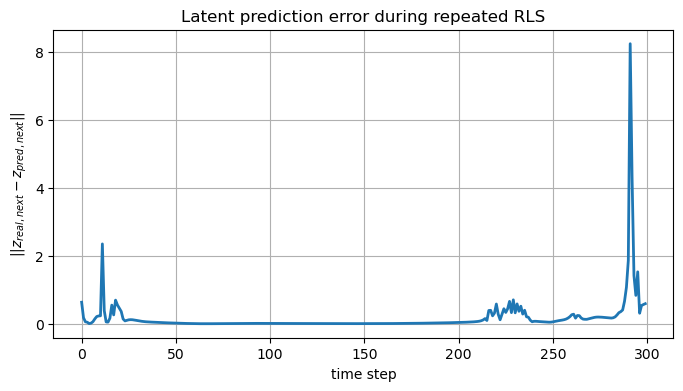

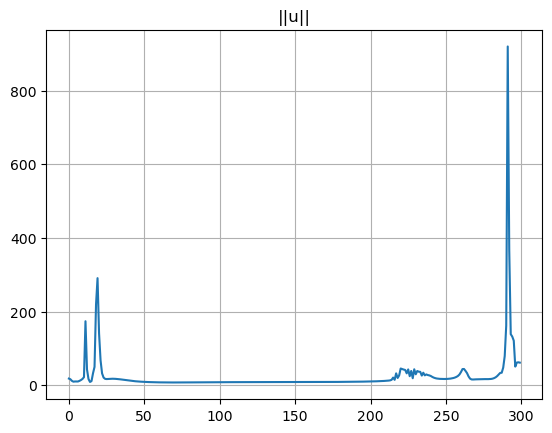

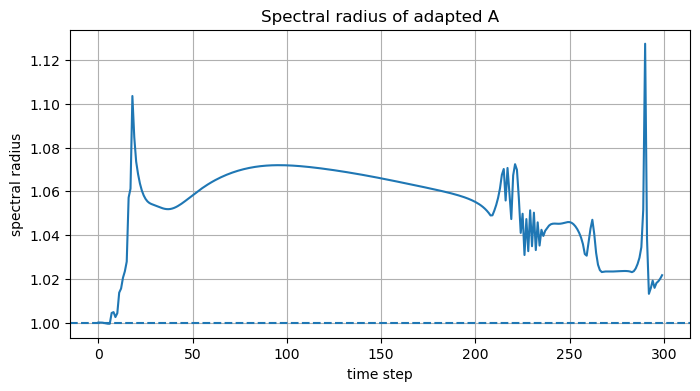

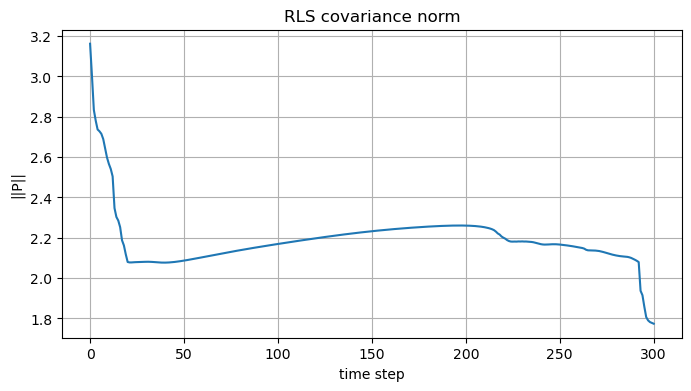

10
100
[np.float64(3.1622776601683795), np.float64(3.00300444822622), np.float64(2.8341522736868243), np.float64(2.7807493329339703), np.float64(2.7371816101188107)]


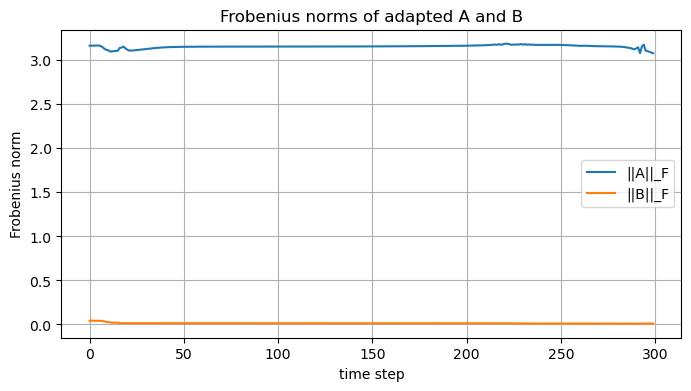

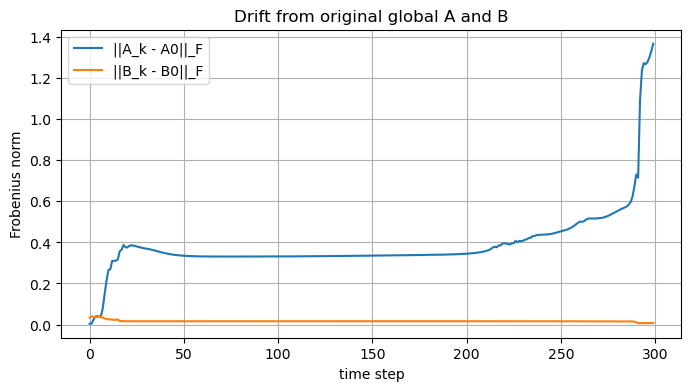

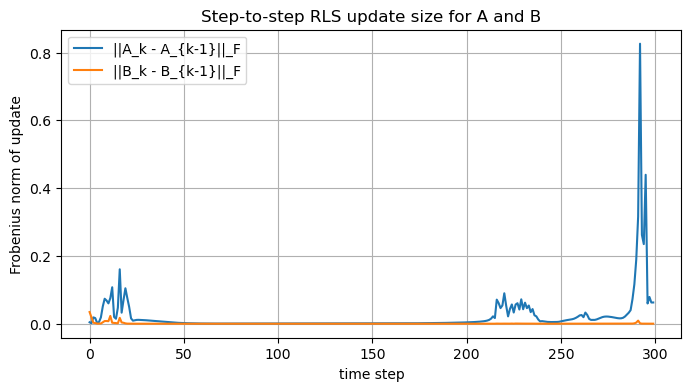

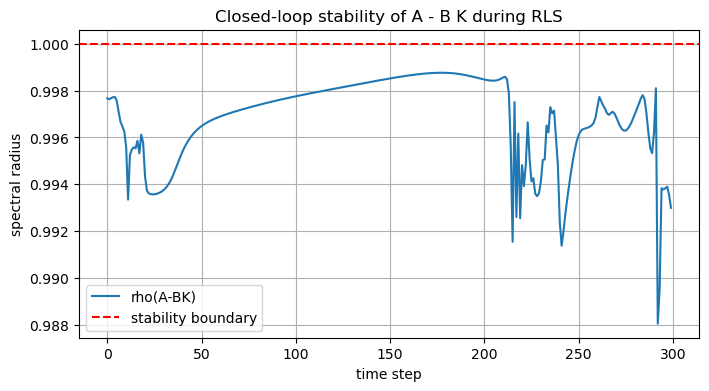

In [33]:
u_norms = np.linalg.norm(u_hist, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(err_norm_hist, linewidth=2)
plt.xlabel("time step")
plt.ylabel(r"$||z_{real,next} - z_{pred,next}||$")
plt.title("Latent prediction error during repeated RLS")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(u_norms)
plt.title("||u||")
plt.grid()

plt.figure(figsize=(8, 4))
plt.plot(rho_hist)
plt.axhline(1.0, linestyle="--")
plt.xlabel("time step")
plt.ylabel("spectral radius")
plt.title("Spectral radius of adapted A")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(P_norm_hist)
plt.xlabel("time step")
plt.ylabel("||P||")
plt.title("RLS covariance norm")
plt.grid(True)
plt.show()

print(len(P))
print(np.size(P))
print(P_norm_hist[0:5])

plt.figure(figsize=(8, 4))
plt.plot(A_fro_hist, label="||A||_F")
plt.plot(B_fro_hist, label="||B||_F")
plt.xlabel("time step")
plt.ylabel("Frobenius norm")
plt.title("Frobenius norms of adapted A and B")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(A0_fro_dev_hist, label="||A_k - A0||_F")
plt.plot(B0_fro_dev_hist, label="||B_k - B0||_F")
plt.xlabel("time step")
plt.ylabel("Frobenius norm")
plt.title("Drift from original global A and B")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(dA_fro_hist, label="||A_k - A_{k-1}||_F")
plt.plot(dB_fro_hist, label="||B_k - B_{k-1}||_F")
plt.xlabel("time step")
plt.ylabel("Frobenius norm of update")
plt.title("Step-to-step RLS update size for A and B")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(rho_cl_hist, label="rho(A-BK)")
plt.axhline(1.0, linestyle="--", color="red", label="stability boundary")
plt.xlabel("time step")
plt.ylabel("spectral radius")
plt.title("Closed-loop stability of A - B K during RLS")
plt.legend()
plt.grid(True)
plt.show()
